In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01000
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1599.5883447509061
RUN  2 , total integrated cost =  562.5522190430502
RUN  3 , total integrated cost =  381.3401400836999
RUN  4 , total integrated cost =  259.31962300181857
RUN  5 , total integrated cost =  185.26895175934928
RUN  6 , total integrated cost =  123.79290908445753
RUN  7 , total integrated cost =  83.34340369158332
RUN  8 , total integrated cost =  67.52230168636208
RUN  9 , total integrated cost =  56.23998268898188
RUN  10 , total integrated cost =  48.7672777690109
RUN  11 , total integrated cost =  42.70752611509773
RUN  12 , total integrated cost =  38.891702393985305
RUN  13 , total integrated cost =  35.44348233569431
RUN  14 , total integrated cost =  33.36580079776461
RUN  15 , total integrated cost =  31.520409153121975
RUN  16 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  541 , total integrated cost =  10.731288953248999
Improved over  541  iterations in  23.024920308962464  seconds by  99.81818790367969  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761516889 -56.62761535889998
weight =  5500.184092472297
set cost params:  1.0 5500.184092472297 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5887.872314935644
Gradient descend method:  None
RUN  1 , total integrated cost =  5419.898533898234
RUN  2 , total integrated cost =  5409.785351697474
RUN  3 , total integrated cost =  5381.901068887319
RUN  4 , total integrated cost =  5373.959426497666
RUN  5 , total integrated cost =  5370.313996193509
RUN  6 , total integrated cost =  5341.536095949515
RUN  7 , total integrated cost =  5331.448689959629
RUN  8 , total integrated cost =  5330.710709756371
RUN  9 , total integrated cost =  5327.412264496114
RUN  10 , total integrated cost =  5311.088032960444
RUN  11 , total integra

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  59 , total integrated cost =  5231.477014093405
Improved over  59  iterations in  1.3514007218182087  seconds by  11.14825977420017  percent.
Problem in initial value trasfer:  Vmean_exc -56.6265817836145 -56.62658040044069
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  2096.0203593937376
RUN  2 , total integrated cost =  762.7557663087949
RUN  3 , total integrated cost =  409.02168600845636
RUN  4 , total integrated cost =  215.3287676507901
RUN  5 , total integrated cost =  144.64864183141978
RUN  6 , total integrated cost =  56.792953770688364
RUN  7 , total integrated cost =  52.532424449493064
RUN  8 , total integrated cost =  48.55215012786419
RUN  9 , total integrated cost =  45.8296811187396
RUN  10 , total integrated cost =  41.57553012328836
RUN  11 , 

...

Control only changes marginally.
RUN  546 , total integrated cost =  60.952280808693025
Improved over  546  iterations in  11.784456880763173  seconds by  99.78773766077585  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408216124247 -56.70408224138484
weight =  4711.151321779964
set cost params:  1.0 4711.151321779964 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28696.554988718795
Gradient descend method:  None
RUN  1 , total integrated cost =  28067.51990713746
RUN  2 , total integrated cost =  28064.91829596517
RUN  3 , total integrated cost =  28064.655706076832
RUN  4 , total integrated cost =  28064.497628540954
RUN  5 , total integrated cost =  28064.35480176732
RUN  6 , total integrated cost =  28063.602742815947
RUN  7 , total integrated cost =  27582.237375921755
RUN  8 , total integrated cost =  27527.766292620563
RUN  9 , total integrated cost =  27527.661162662353
RUN  10 , total integrated cost =  27527.657281620162
RUN  11 , to

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  27527.65721961059
RUN  17 , total integrated cost =  27527.65721961059
Control only changes marginally.
RUN  17 , total integrated cost =  27527.65721961059
Improved over  17  iterations in  0.43706367909908295  seconds by  4.073303466453453  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408378536532 -56.70408370628677
-------  119 0.5250000000000001 0.8250000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23752.516518906425
Gradient descend method:  None
RUN  1 , total integrated cost =  23752.516484636933
RUN  2 , total integrated cost =  23752.51648463693
RUN  3 , total integrated cost =  23752.51648463693
Control only changes marginally.
RUN  3 , total integrated cost =  23752.51648463693
Improved over  3  iterations in  0.1466740407049656  seconds by  1.4427732253352588e-07  percent.
Problem in initial value trasfer:  Vmean_exc -73.23563834178628 -73.23566620527959
wei

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23752.51648463693
Control only changes marginally.
RUN  1 , total integrated cost =  23752.51648463693
Improved over  1  iterations in  0.05978282354772091  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.23563834178628 -73.23566620527959
-------  126 0.5000000000000002 0.8500000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19001.9785373305
Gradient descend method:  None
RUN  1 , total integrated cost =  19001.978537298924
RUN  2 , total integrated cost =  19001.978537298914
RUN  3 , total integrated cost =  19001.978537298914
Control only changes marginally.
RUN  3 , total integrated cost =  19001.978537298914
Improved over  3  iterations in  0.10138756781816483  seconds by  1.6622436760371784e-10  percent.
Problem in initial value trasfer:  Vmean_exc -75.95963593546153 -75.9596367734306
weight =  10.000000000016621
set cost params:  1.0 10.000000000016621 0.

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


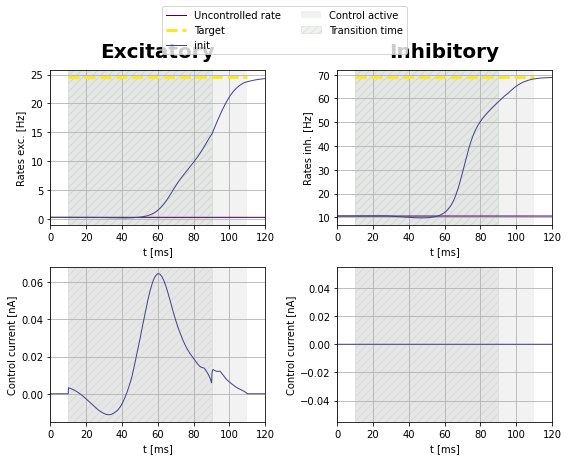

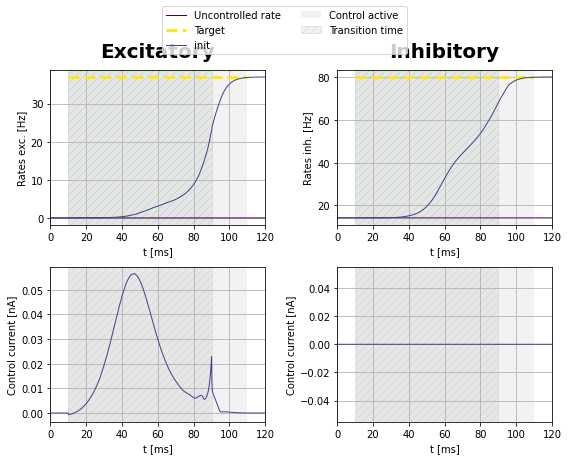

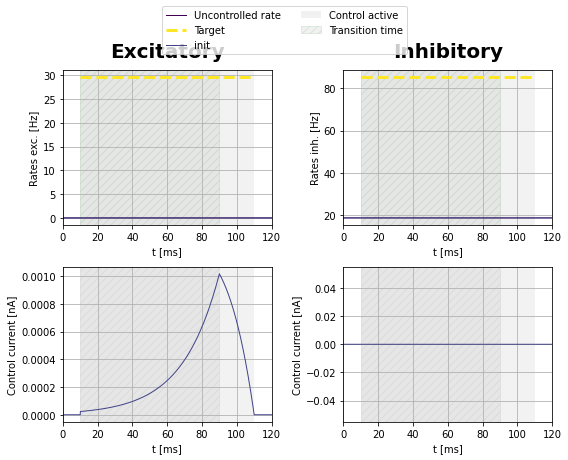

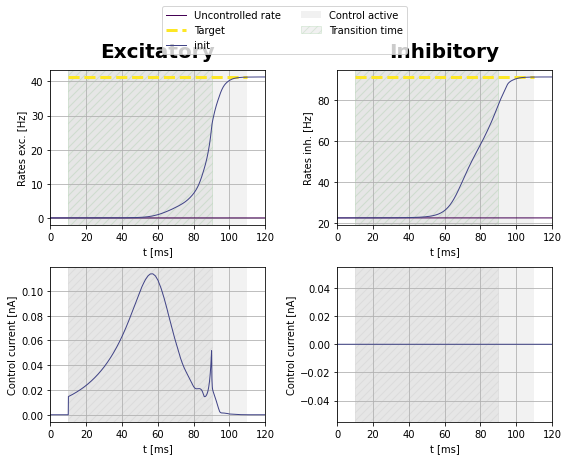

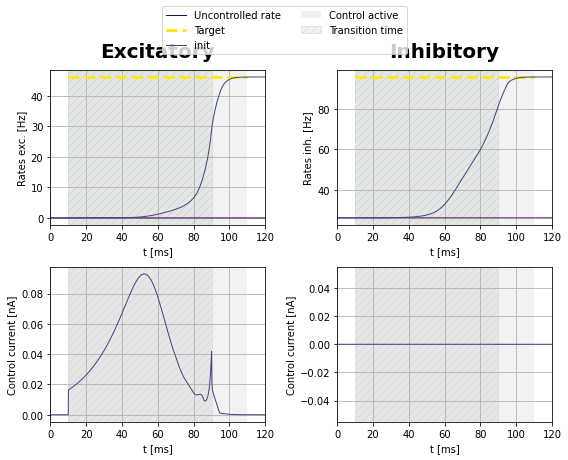

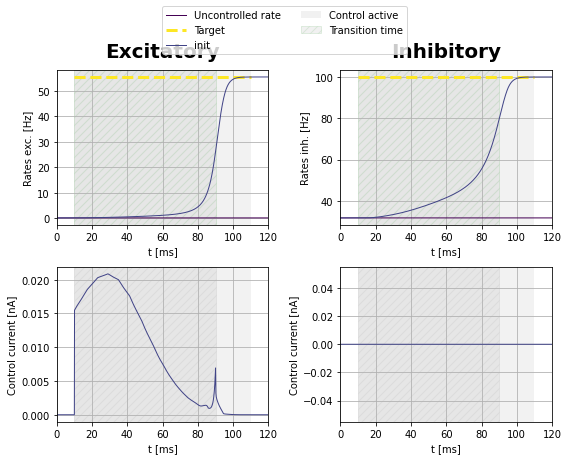

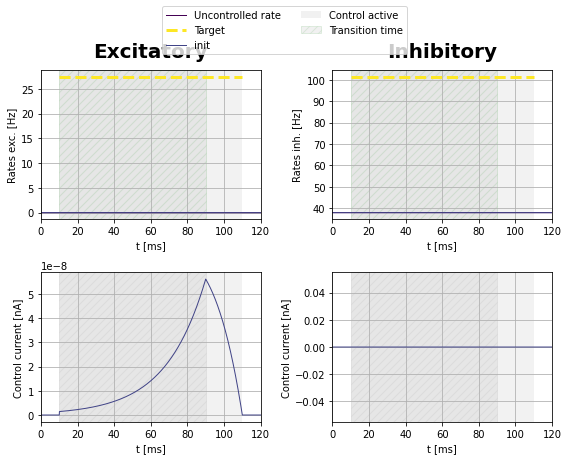

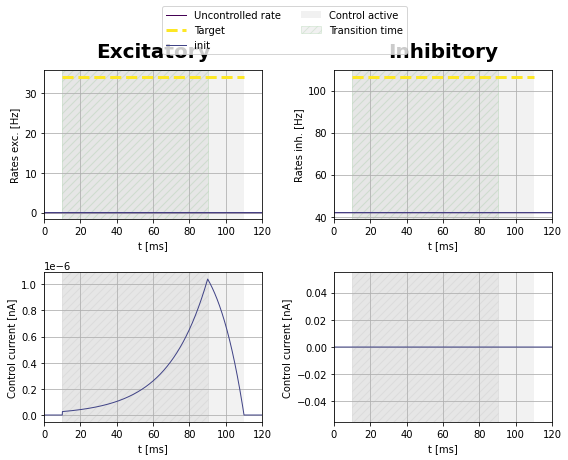

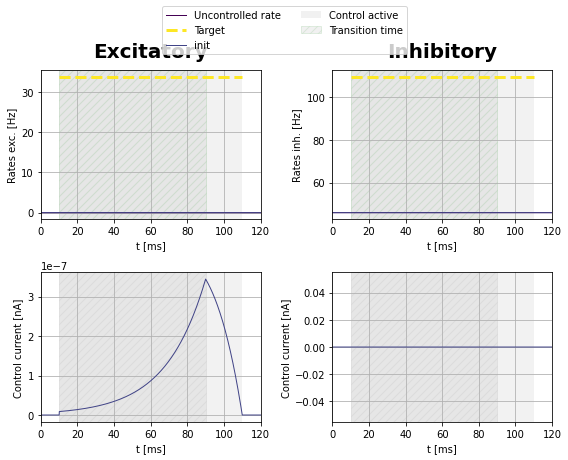

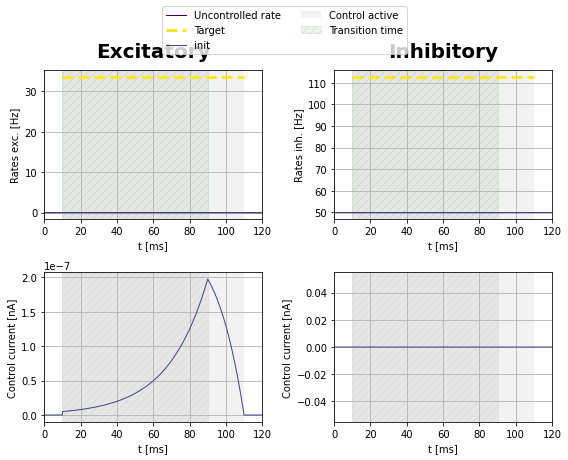

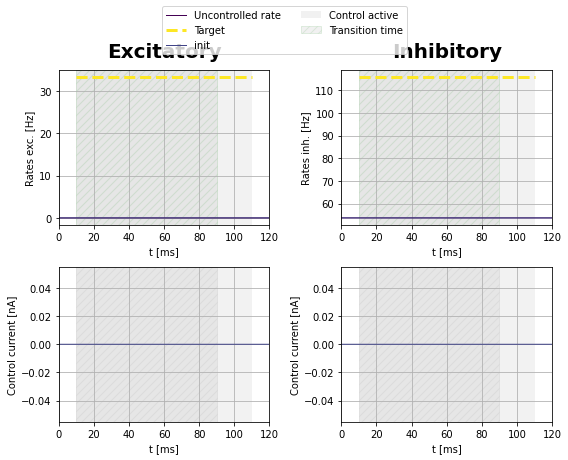

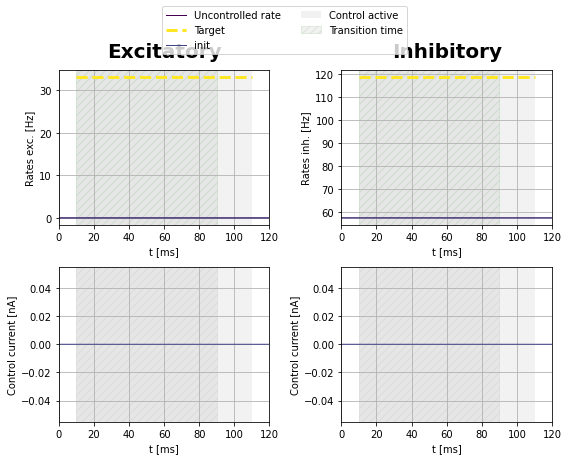

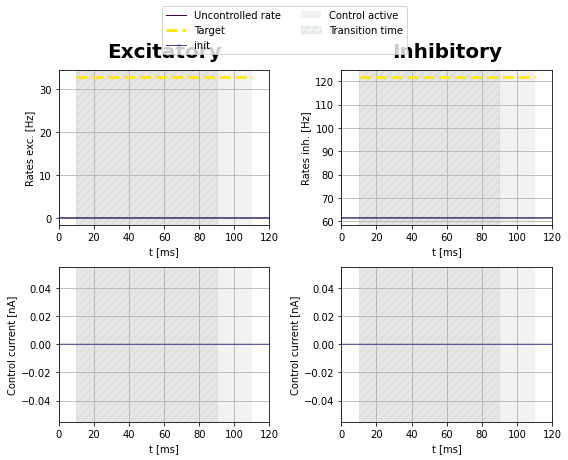

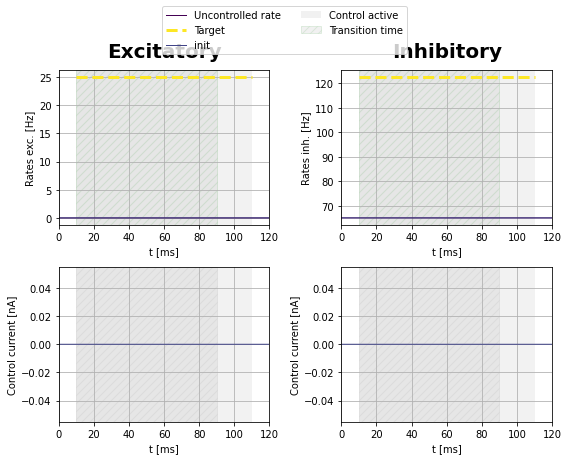

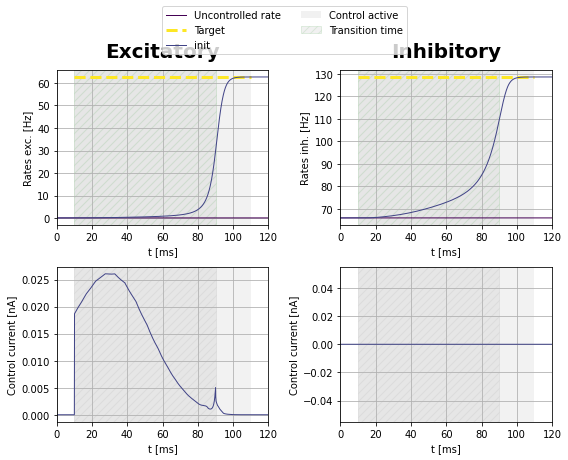

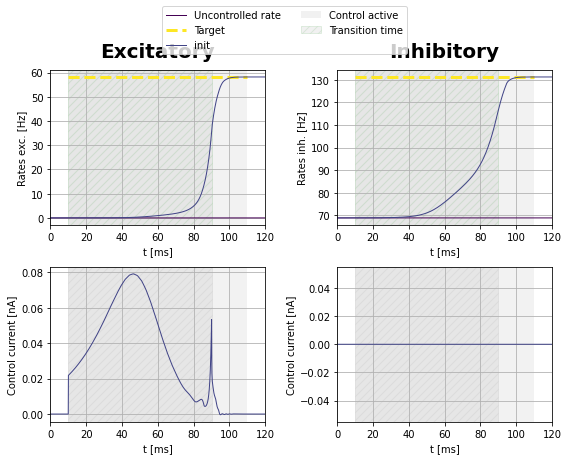

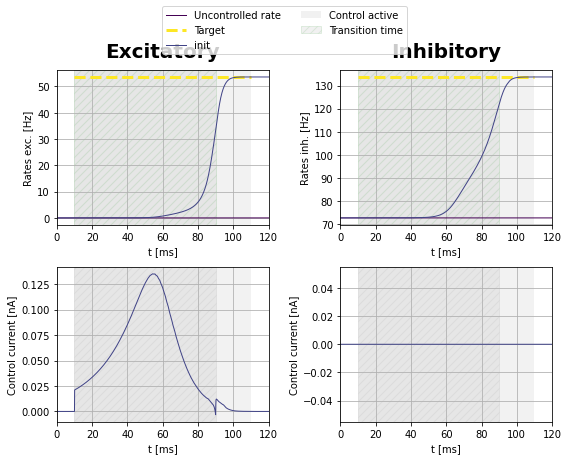

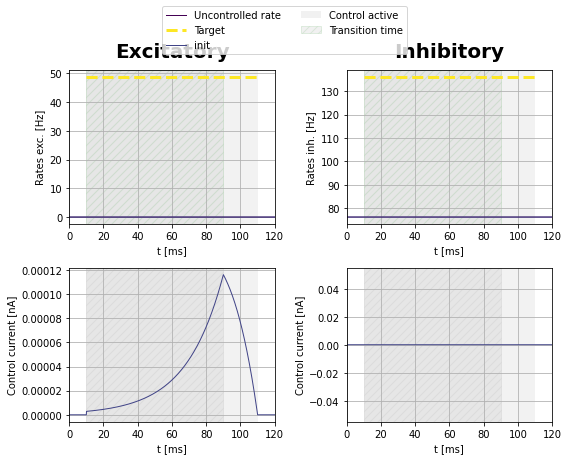

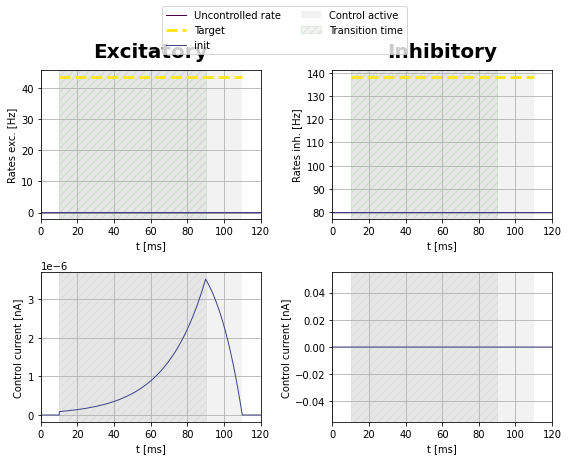

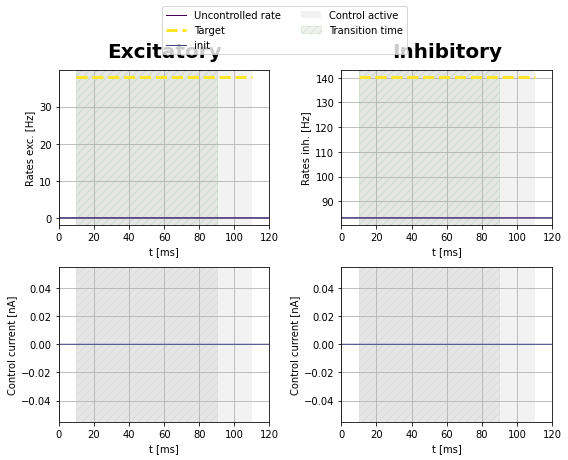

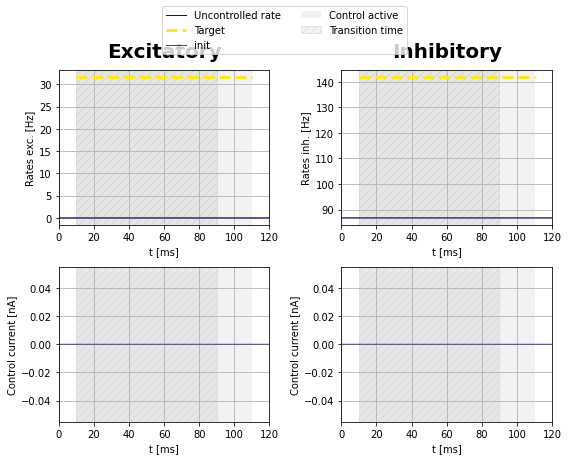

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
[0, 7] []
closest index  7
set c

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  8796.17296708896
Control only changes marginally.
RUN  7 , total integrated cost =  8796.17296708896
Improved over  7  iterations in  0.20243138819932938  seconds by  0.09254960224708952  percent.
Problem in initial value trasfer:  Vmean_exc -71.31177454554573 -71.31201102243905
weight =  10.000002948564978
set cost params:  1.0 10.000002948564978 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.17296708963
Gradient descend method:  None
RUN  1 , total integrated cost =  8796.17296708963
Control only changes marginally.
RUN  1 , total integrated cost =  8796.17296708963
Improved over  1  iterations in  0.05984792858362198  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.31177454554573 -71.31201102243905
-------  21 0.47500000000000014 0.4750000000000002
found solution for  21
-------  28 0.5000000000000002 0.5000000000000002
found solution for  28
-------  35 0.5500000000000003 0.52500000000000

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  7519.183505039447
Control only changes marginally.
RUN  5 , total integrated cost =  7519.183505039447
Improved over  5  iterations in  0.14652813971042633  seconds by  0.38800821287345855  percent.
Problem in initial value trasfer:  Vmean_exc -78.72375596381706 -78.723755979259
weight =  10.000000000000021
set cost params:  1.0 10.000000000000021 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7519.183505039447
Gradient descend method:  None
RUN  1 , total integrated cost =  7519.183505039447
Control only changes marginally.
RUN  1 , total integrated cost =  7519.183505039447
Improved over  1  iterations in  0.050417426973581314  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -78.72375596381706 -78.723755979259
-------  49 0.4500000000000001 0.6000000000000003
[0, 7, 21, 28, 35] []
closest index  28
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , to

...

RUN  7 , total integrated cost =  23752.51648491896
Control only changes marginally.
RUN  7 , total integrated cost =  23752.51648491896
Improved over  7  iterations in  0.19466991908848286  seconds by  0.03783764283859625  percent.
Problem in initial value trasfer:  Vmean_exc -73.23605085967672 -73.23607681300732
weight =  10.000000014308995
set cost params:  1.0 10.000000014308995 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23752.51648491896
Gradient descend method:  None
RUN  1 , total integrated cost =  23752.51648491896
Control only changes marginally.
RUN  1 , total integrated cost =  23752.51648491896
Improved over  1  iterations in  0.0582218412309885  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.23605085967672 -73.23607681300732
-------  126 0.5000000000000002 0.8500000000000005
[0, 7, 21, 28, 35, 98, 105, 112] [112, 105, 98, 35, 28, 21, 7]
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interp

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  19001.97853729914
Control only changes marginally.
RUN  5 , total integrated cost =  19001.97853729914
Improved over  5  iterations in  0.1483820267021656  seconds by  0.047665123666035925  percent.
Problem in initial value trasfer:  Vmean_exc -75.95964868475004 -75.95964946407827
weight =  10.000000000016502
set cost params:  1.0 10.000000000016502 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19001.97853729914
Gradient descend method:  None
RUN  1 , total integrated cost =  19001.97853729914
Control only changes marginally.
RUN  1 , total integrated cost =  19001.97853729914
Improved over  1  iterations in  0.0539245530962944  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.95964868475004 -75.95964946407827
-------  133 0.47500000000000014 0.8750000000000006
[0, 7, 21, 28, 35, 98, 105, 112] [112, 105, 98, 35, 28, 21, 7]
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
inter

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  14446.643021512598
Control only changes marginally.
RUN  6 , total integrated cost =  14446.643021512598
Improved over  6  iterations in  0.16782859154045582  seconds by  0.06270469723939698  percent.
Problem in initial value trasfer:  Vmean_exc -78.65803955722382 -78.65803957474758
weight =  10.0
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14446.643021512598
Gradient descend method:  None
RUN  1 , total integrated cost =  14446.643021512598
Control only changes marginally.
RUN  1 , total integrated cost =  14446.643021512598
Improved over  1  iterations in  0.05160411447286606  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -78.65803955722382 -78.65803957474758
-------  140 0.4500000000000001 0.9000000000000006
[0, 7, 21, 28, 35, 98, 105, 112] [112, 105, 98, 35, 28, 21, 7]
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True 

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6204.57485714927
set cost params:  1.0 6204.57485714927 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5869.970943977711
Gradient descend method:  None
RUN  1 , total integrated cost =  5868.995593184331
RUN  2 , total integrated cost =  5868.9690593624355
RUN  3 , total integrated cost =  5868.964122544004
RUN  4 , total integrated cost =  5868.963129610927
RUN  5 , total integrated cost =  5868.96291591427
RUN  6 , total integrated cost =  5868.9628147608255
RUN  7 , total integrated cost =  5868.96277552759
RUN  8 , total integrated cost =  5868.96276

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  5868.962762609469
RUN  20 , total integrated cost =  5868.962762609469
Control only changes marginally.
RUN  20 , total integrated cost =  5868.962762609469
Improved over  20  iterations in  0.5115602239966393  seconds by  0.017175236093393664  percent.
Problem in initial value trasfer:  Vmean_exc -56.62638497538138 -56.62638527316945
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  15874.387284923601
set cost params:  1.0 15874.387284923601 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13537.048116222812
Gradient descend method:  None
RUN  1 , total integrated cost =  13536.906513091368
RUN  2 , total integrated cost =  13536.886286928873
RUN  3 , total integrated cost =  13536.880094366192
RUN  4 , total integrated cost =  13536.877579918331
RUN  5 , total integrated cost =  13536.876558583226
RUN  6 , total integrated cost =  13536.875948455598
RUN  7 , total integrated cost =  13536.875403472

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  27 , total integrated cost =  13536.873321218567
Improved over  27  iterations in  0.6149348895996809  seconds by  0.00129123426869171  percent.
Problem in initial value trasfer:  Vmean_exc -56.673651164922006 -56.67366374370641
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
no convergence
weight =  4168.459592356078
set cost params:  1.0 4168.459592356078 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17056.16229093535
Gradient descend method:  None
RUN  1 , total integrated cost =  17056.073082040424
RUN  2 , total integrated cost =  17056.06333241868
RUN  3 , total integrated cost =  17056.06173567081
RUN  4 , total integrated cost =  17056.061564748336
RUN  5 , total integrated cost =  17056.061527148744
RUN  6 , total integrated cost =  17056.06152136679
RUN  7 , total integrated cost =  17056.061520540192


...

RUN  2 , total integrated cost =  28709.701631396325
RUN  3 , total integrated cost =  28709.701631396325
Control only changes marginally.
RUN  3 , total integrated cost =  28709.701631396325
Improved over  3  iterations in  0.19450297020375729  seconds by  5.684341886080802e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.704083747291705 -56.70408366981008
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
[[True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000

ERROR:root:Problem in initial value trasfer


interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33888.67150331073
Gradient descend method:  None
RUN  1 , total integrated cost =  33888.67150331073
Control only changes marginally.
RUN  1 , total integrated cost =  33888.67150331073
Improved over  1  iterations in  0.0816588494926691  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70334559957457 -56.70334550958754
-------  112 0.5500000000000003 0.8000000000000005
no convergence
weight =  4915.877844050427
set cost params:  1.0 4915.877844050427 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28709.70163139636
Gradient descend method:  None
RUN  1 , total integrated cost =  28709.701631396354


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  28709.701631396354
Control only changes marginally.
RUN  2 , total integrated cost =  28709.701631396354
Improved over  2  iterations in  0.13955450803041458  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.704083747291705 -56.70408366981008
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
[[True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  292.21617302757835
Gradient descend method:  None
RUN  1 , total integrated cost =  29.310669966931478
RUN  2 , total integrated cost =  17.825197256577727
RUN  3 , total integrated cost =  16.20922382913763
RUN  4 , total integrated cost =  15.921539819202902
RUN  5 , total integrated cost =  15.644793380809404
RUN  6 , total integrated cost =  15.497933195049274
RUN  7 , total integrated cost =  15.330837227477199
RUN  8 , total integrated cost =  15.224476800709478
RUN  9 , total integrated cost =  15.066392154502148
RUN  10 , total integrated cost =  14.964853665954873
RUN  11 , total integrated cost =  14.820531785393285
RUN  12 , total integrated cost =  14.728608322069741
RUN  13 , total integrated cost =  14.567183832023678
RUN  14 , total integrated cost =  14.518629889981309
RUN  15 , total integrated cost =  14.45194721319607

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  13.50991025959523
RUN  1000 , total integrated cost =  13.50991025959523
Improved over  1000  iterations in  48.737634755671024  seconds by  95.37674108875548  percent.
Problem in initial value trasfer:  Vmean_exc -56.6276217060655 -56.62762168364122
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  59.911574850074494
Gradient descend method:  HS
RUN  1 , total integrated cost =  59.6612209035999
RUN  2 , total integrated cost =  59.20946805754178
RUN  3 , total integrated cost =  58.939277367937436
RUN  4 , total integrated cost =  58.85155395179072
RUN  5 , total integrated cost =  58.568953925097716
RUN  6 , total integrated cost =  58.39545284321722
RUN  7 , total integrated cost =  58.12870300955753
RUN  8 , total integrated cost =  57.8484114323896
RUN  9 , total integrated cost =  57.84683962677531
RUN  10 , total integrated cost =  57.54232313033156
RUN  11 , total integrate

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  56.715287880732554
Control only changes marginally.
RUN  15 , total integrated cost =  56.715287880732554
Improved over  15  iterations in  1.1527828965336084  seconds by  5.3350074294332614  percent.
Problem in initial value trasfer:  Vmean_exc -56.62763278404715 -56.62763294131573
weight =  10406.081934681606
set cost params:  1.0 10406.081934681606 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5882.190572502685
Gradient descend method:  None
RUN  1 , total integrated cost =  5284.515426856433
RUN  2 , total integrated cost =  5084.415804739913
RUN  3 , total integrated cost =  4671.518590266276
RUN  4 , total integrated cost =  4551.462270965824
RUN  5 , total integrated cost =  4369.147553989723
RUN  6 , total integrated cost =  4275.135109985056
RUN  7 , total integrated cost =  4153.089979855478
RUN  8 , total integrated cost =  4082.249315864382
RUN  9 , total integrated cost =  3996.184780693125
RUN  10 , total in

...

Problem in initial value trasfer:  Vmean_exc -75.95980006262016 -75.95980014562048
weight =  99.00000000001654
set cost params:  1.0 99.00000000001654 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19001.978537327323
Gradient descend method:  None
RUN  1 , total integrated cost =  19001.978537327323
Control only changes marginally.
RUN  1 , total integrated cost =  19001.978537327323
Improved over  1  iterations in  0.13674377650022507  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.95980006262016 -75.95980014562048
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14446.643038727443
Gradient descend method:  None
RUN  1 , total integrated cost =  14446.64302217911
RUN  2 , total integrated cost =  14446.64302152718
RUN  3 , total integrated cost =  14446.643021512627
RUN  4 , total integrated cost =  14446.6430215126
RUN  5 ,

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  3053.128558691842
Control only changes marginally.
RUN  40 , total integrated cost =  3053.128558691842
Improved over  40  iterations in  3.288247315213084  seconds by  2.264577141516355  percent.
Problem in initial value trasfer:  Vmean_exc -56.652273488689275 -56.65225435103233
weight =  327.18691797490095
set cost params:  1.0 327.18691797490095 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9978.525494207815
Gradient descend method:  None
RUN  1 , total integrated cost =  9969.316901563661
RUN  2 , total integrated cost =  9968.981250575986
RUN  3 , total integrated cost =  9968.860007226212
RUN  4 , total integrated cost =  9968.860007226196
RUN  5 , total integrated cost =  9968.860007226192
RUN  6 , total integrated cost =  9968.860007226185
RUN  7 , total integrated cost =  9968.860007226183


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  9968.860007226183
Control only changes marginally.
RUN  8 , total integrated cost =  9968.860007226183
Improved over  8  iterations in  0.8084759712219238  seconds by  0.09686287805990901  percent.
Problem in initial value trasfer:  Vmean_exc -56.65190576548841 -56.65189296575601


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


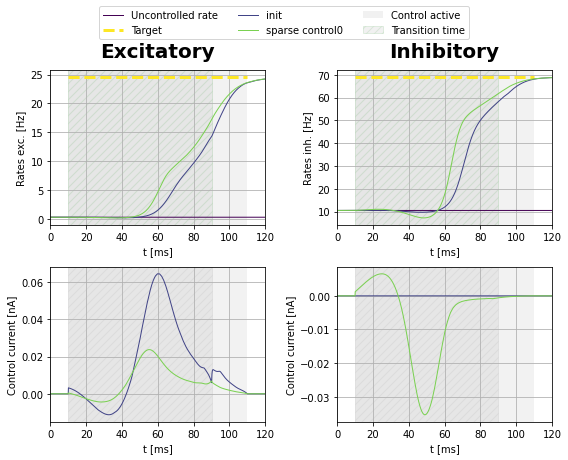

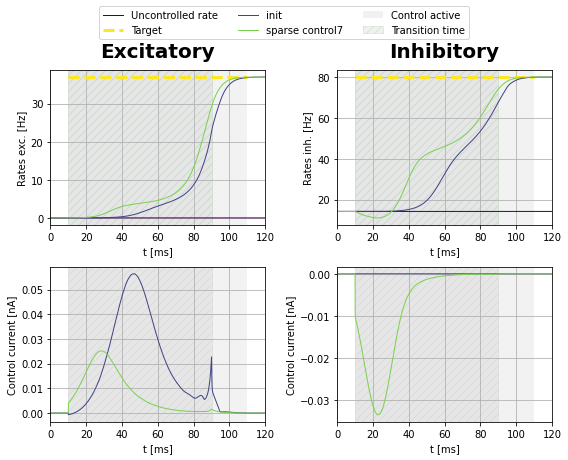

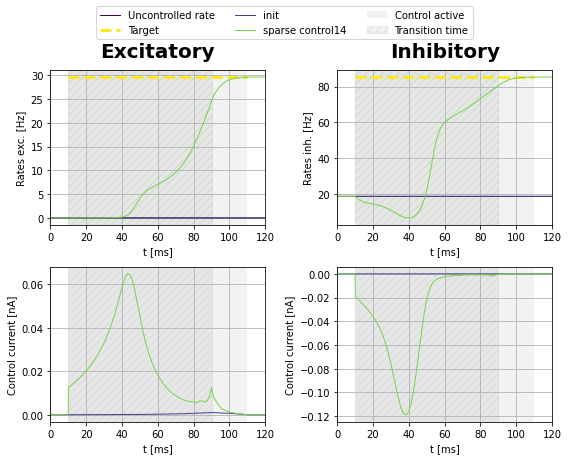

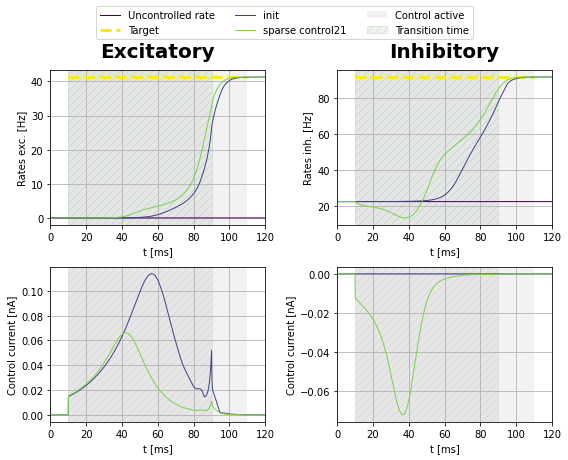

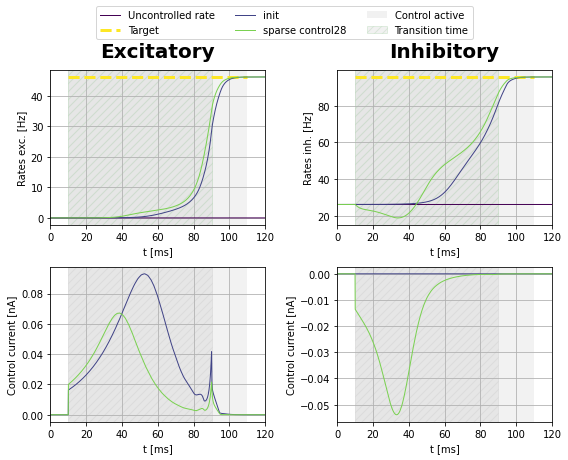

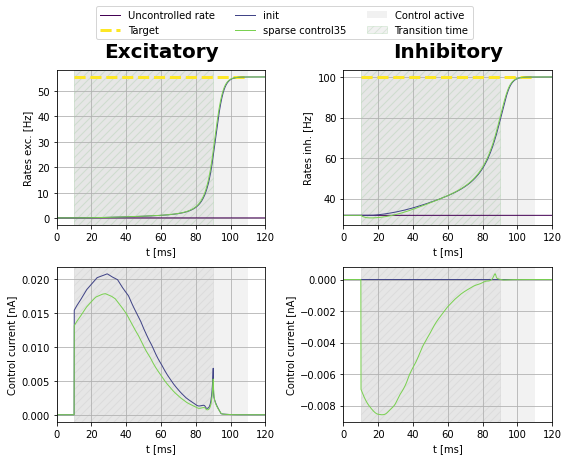

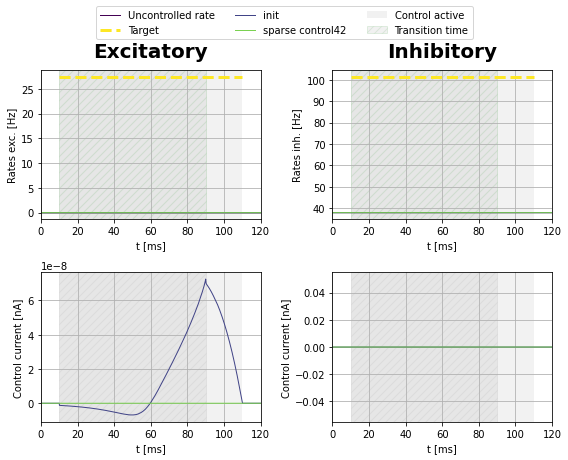

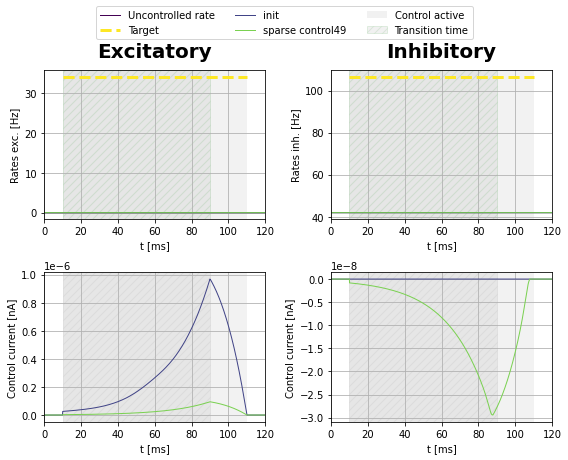

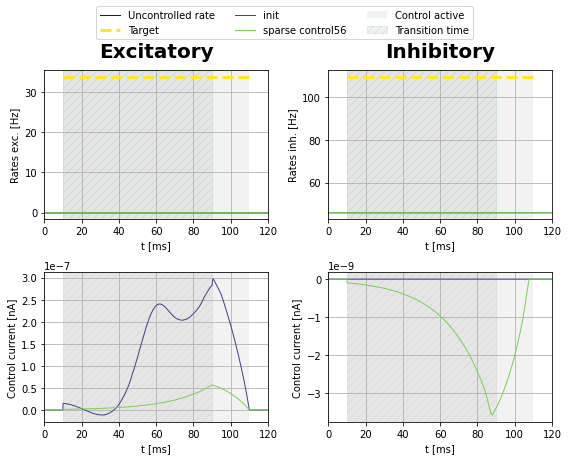

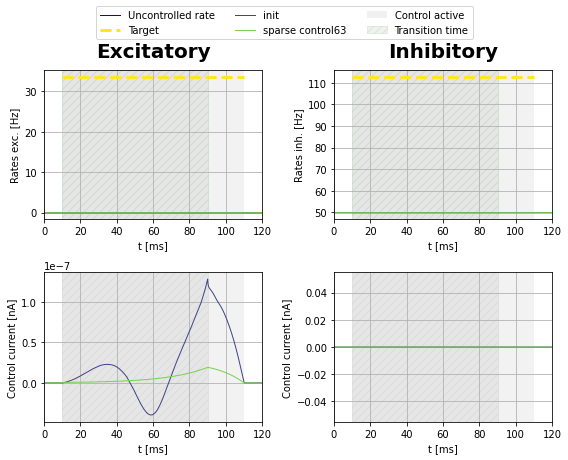

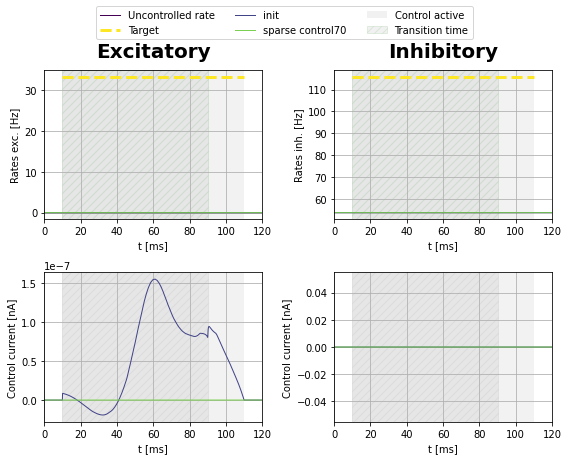

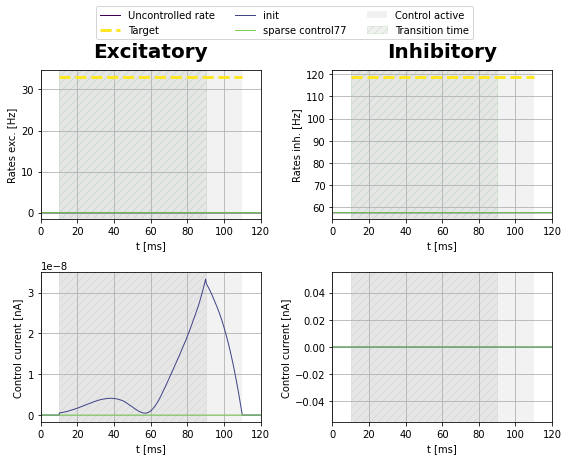

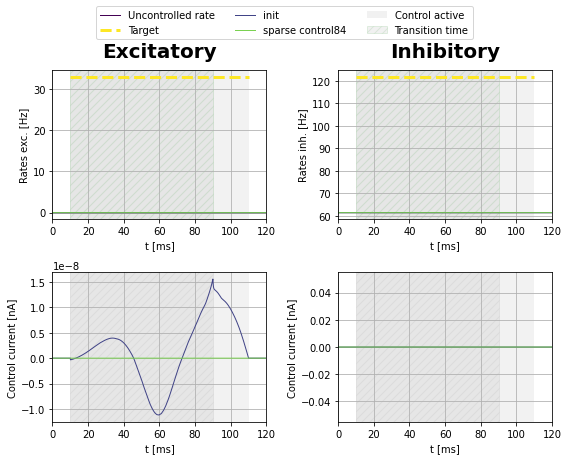

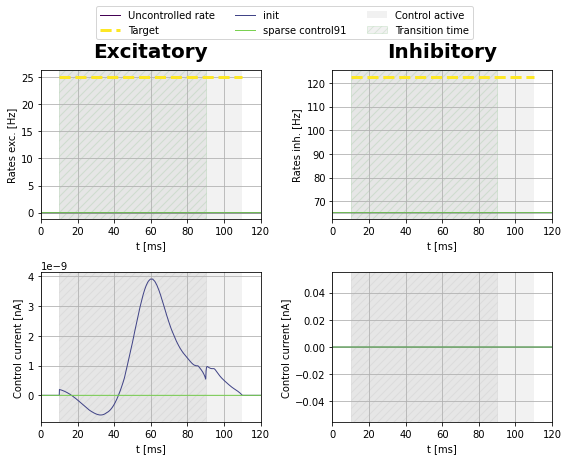

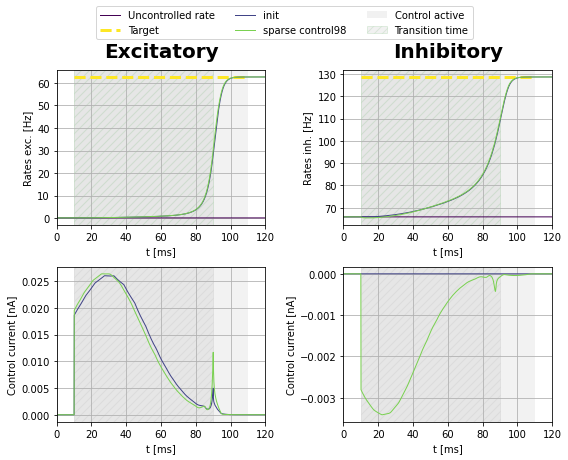

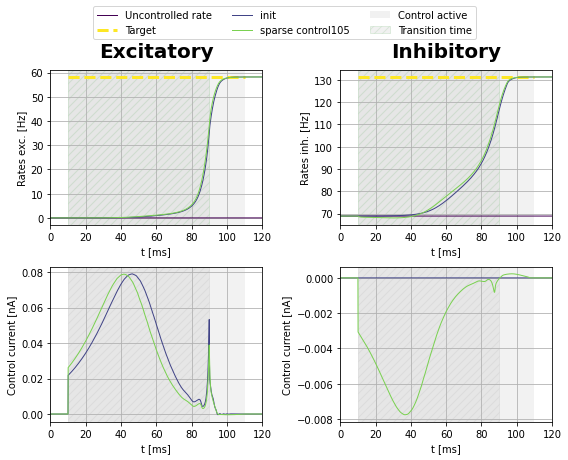

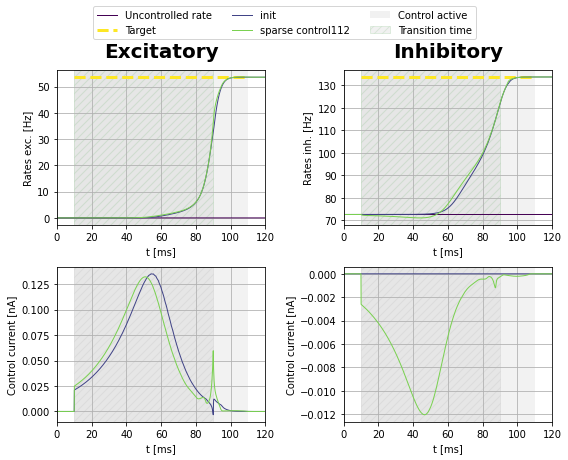

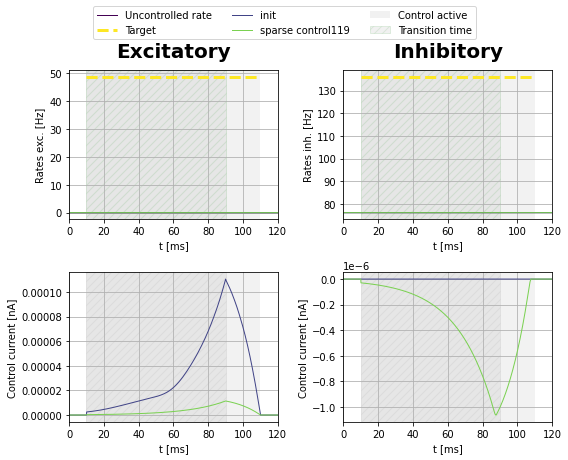

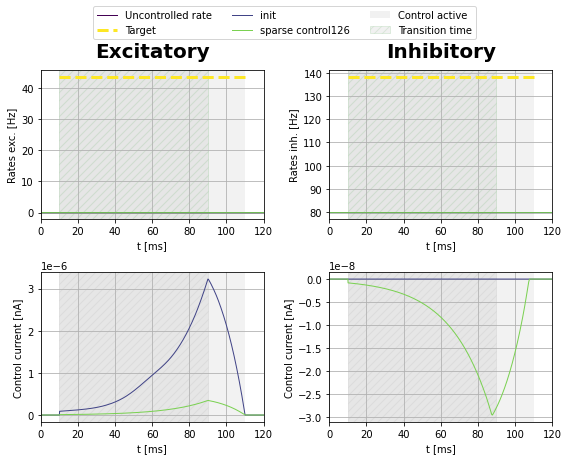

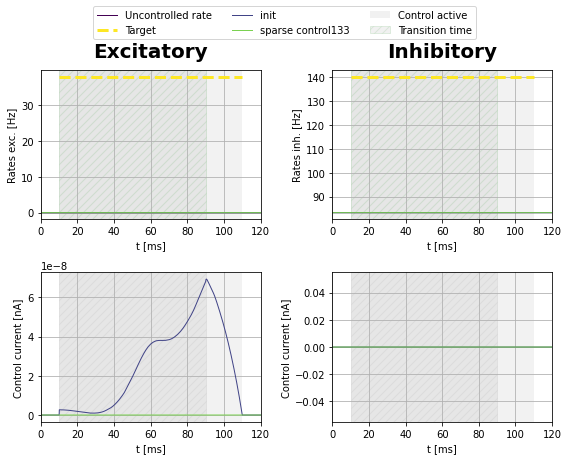

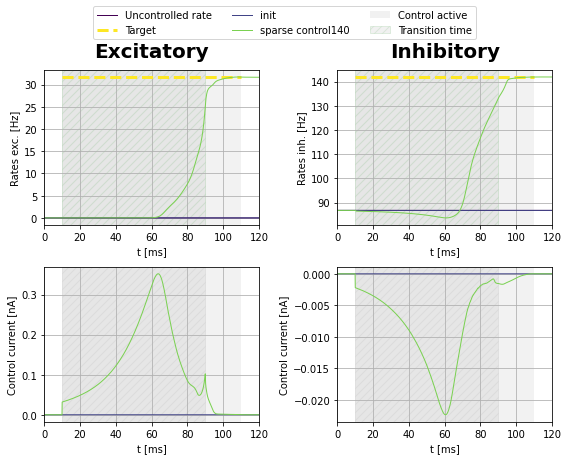

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  17284.027881391263
set cost params:  1.0 17284.027881391263 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5804.688429890043
Gradient descend method:  None
RUN  1 , total integrated cost =  5783.770101409774
RUN  2 , total integrated cost =  5783.656377705494
RUN  3 , total integrated cost =  5783.633627428555
RUN  4 , total integrated cost =  5783.622730872246
RUN  5 , total integrated cost =  5783.614731181821
RUN  6 , total integrated cost =  5783.605202890011
RUN  7 , total integrated cost =  5783.587052108738
RUN  8 , total integra

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  5774.000088598937
RUN  20 , total integrated cost =  5774.000088598937
Control only changes marginally.
RUN  20 , total integrated cost =  5774.000088598937
Improved over  20  iterations in  1.8318488635122776  seconds by  0.5286819725427989  percent.
Problem in initial value trasfer:  Vmean_exc -56.626034516663125 -56.62603340962758
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  39136.28735385173
set cost params:  1.0 39136.28735385173 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13541.779033169216
Gradient descend method:  None
RUN  1 , total integrated cost =  13541.070788844345
RUN  2 , total integrated cost =  13541.070333510434
RUN  3 , total integrated cost =  13541.07033343344
RUN  4 , total integrated cost =  13541.070333433401
RUN  5 , total integrated cost =  13541.07033343339
State only changes marginally.
RUN  6 , total integrated cost =  13541.070333433388
State only changes marg

ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  13541.070333433385
RUN  8 , total integrated cost =  13541.070333433385
Control only changes marginally.
RUN  8 , total integrated cost =  13541.070333433385
Improved over  8  iterations in  1.0336018837988377  seconds by  0.005233431546145084  percent.
Problem in initial value trasfer:  Vmean_exc -56.673956582677505 -56.67396180070432
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2445.9533610952553
set cost params:  1.0 2445.9533610952553 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8792.328641521517
Gradient descend method:  None
RUN  1 , total integrated cost =  8792.32756516026
RUN  2 , total integrated cost =  8792.327564288094


...

RUN  3 , total integrated cost =  39221.17483701744
Control only changes marginally.
RUN  3 , total integrated cost =  39221.17483701744
Improved over  3  iterations in  0.5682972222566605  seconds by  1.7053025658242404e-13  percent.
Problem in initial value trasfer:  Vmean_exc -56.69977190694301 -56.69977176288214
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 9
[[True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, False], [True, False]

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  2 , total integrated cost =  39221.17483701747
Improved over  2  iterations in  0.4168675485998392  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.69977190694301 -56.69977176288214
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 10
[[True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  39221.17483701749
Control only changes marginally.
RUN  1 , total integrated cost =  39221.17483701749
Improved over  1  iterations in  0.21108920872211456  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69977190694301 -56.69977176288214
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 11
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  241.9145254484979
Gradient descend method:  None
RUN  1 , total integrated cost =  2.3789322791704635
RUN  2 , total integrated cost =  0.8532048320965614
RUN  3 , total integrated cost =  0.5966182634776159
RUN  4 , total integrated cost =  0.5234628091514015
RUN  5 , total integrated cost =  0.47787968519547425
RUN  6 , total integrated cost =  0.45549104002203566
RUN  7 , total integrated cost =  0.43934096657693056
RUN  8 , total integrated cost =  0.4297503201545575
RUN  9 , total integrated cost =  0.421882869441112
RUN  10 , total integrated cost =  0.4177466064677798
RUN  11 , total integrated cost =  0.4142009391940342
RUN  12 , total integrated cost =  0.4118696072536647
RUN  13 , total integrated cost =  0.40962519291494426
RUN  14 , total integrated cost =  0.408077943245598
RUN  15 , total integrated cost =  0.40642319214103

ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  154 , total integrated cost =  0.3797885615618397
Improved over  154  iterations in  3.4667662531137466  seconds by  99.8430071278863  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762011534211 -56.6276201037505
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  78.9833093764574
Gradient descend method:  None
RUN  1 , total integrated cost =  0.3827424086284918
RUN  2 , total integrated cost =  0.3702796584472382
RUN  3 , total integrated cost =  0.36744300837789917
RUN  4 , total integrated cost =  0.36654394744413293
RUN  5 , total integrated cost =  0.36598394928040345
RUN  6 , total integrated cost =  0.36568942884326283
RUN  7 , total integrated cost =  0.36536645637053905
RUN  8 , total integrated cost =  0.36514554960147705
RUN  9 , total integrated cost =  0.3647628497035596
RUN  10 , total integr

ERROR:root:Problem in initial value trasfer


RUN  200 , total integrated cost =  3.6218107359058047
Control only changes marginally.
RUN  206 , total integrated cost =  3.621810735905793
Improved over  206  iterations in  4.484647583216429  seconds by  89.67399824351287  percent.
Problem in initial value trasfer:  Vmean_exc -56.64410413357788 -56.64410410971307
-------  21 0.47500000000000014 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  87.30876731801447
Gradient descend method:  None
RUN  1 , total integrated cost =  2.4470718301210956
RUN  2 , total integrated cost =  2.3437330675733574
RUN  3 , total integrated cost =  2.296890679278832
RUN  4 , total integrated cost =  2.2805791667629634
RUN  5 , total integrated cost =  2.2711564210059363
RUN  6 , total integrated cost =  2.2634319606698736
RUN  7 , total integrated cost =  2.258737840507387
RUN  8 , total integrated cost =  2.2543868168104733
RUN  9 , total integrated cost =  2.2516006206232446
RUN 

...

RUN  80 , total integrated cost =  0.34288857749475204
Control only changes marginally.
RUN  84 , total integrated cost =  0.34288857749462087
Improved over  84  iterations in  1.8984716143459082  seconds by  99.96542137793153  percent.
Problem in initial value trasfer:  Vmean_exc -56.69976828388218 -56.69976827205077
-------  105 0.5750000000000002 0.7750000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  272.0705008770087
Gradient descend method:  None
RUN  1 , total integrated cost =  2.5384418479020754
RUN  2 , total integrated cost =  2.4992466474667694
RUN  3 , total integrated cost =  2.4530390912240643
RUN  4 , total integrated cost =  2.440932651715557
RUN  5 , total integrated cost =  2.434492004245779
RUN  6 , total integrated cost =  2.4296622571983972
RUN  7 , total integrated cost =  2.424536606541955
RUN  8 , total integrated cost =  2.420403105613638
RUN  9 , total integrated cost =  2.4096603045701173
RUN  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  23752.516176039746
RUN  4 , total integrated cost =  23752.516176039746
Control only changes marginally.
RUN  4 , total integrated cost =  23752.516176039746
Improved over  4  iterations in  0.12395678646862507  seconds by  1.415474358168467e-06  percent.
Problem in initial value trasfer:  Vmean_exc -73.18052365368747 -73.18080676650433
-------  126 0.5000000000000002 0.8500000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19001.9785373244
Gradient descend method:  None
RUN  1 , total integrated cost =  19001.978537014034
RUN  2 , total integrated cost =  19001.978537013976
RUN  3 , total integrated cost =  19001.978537013973
RUN  4 , total integrated cost =  19001.978537013973
Control only changes marginally.
RUN  4 , total integrated cost =  19001.978537013973
Improved over  4  iterations in  0.11787799745798111  seconds by  1.6336656472049071e-09  percent.
Problem in initial value tras

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14446.643021512537
RUN  2 , total integrated cost =  14446.643021512537
Control only changes marginally.
RUN  2 , total integrated cost =  14446.643021512537
Improved over  2  iterations in  0.07251493632793427  seconds by  4.263256414560601e-13  percent.
Problem in initial value trasfer:  Vmean_exc -78.65803265543195 -78.65803270458842
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  51.58032038171531
Gradient descend method:  None
RUN  1 , total integrated cost =  33.163987147293874
RUN  2 , total integrated cost =  33.11448319651806
RUN  3 , total integrated cost =  32.99378769723512
RUN  4 , total integrated cost =  32.91240237186878
RUN  5 , total integrated cost =  32.200740917935406
RUN  6 , total integrated cost =  31.860718103163684
RUN  7 , total integrated cost =  31.288694405109844
RUN  8 , total integrated cost =  31.279194452403768
RUN 

In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.3797885615618397
Gradient descend method:  None
RUN  1 , total integrated cost =  0.3797885615618397
Control only changes marginally.
RUN  1 , total integrated cost =  0.3797885615618397
Improved over  1  iterations in  0.06437063403427601  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762011534211 -56.6276201037505
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.621810735905793
Control only changes marginally.
RUN  1 , total integrated cost =  3.621810735905793
Improved over  1  iterations in  0.0670638158917427  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64410413357788 -56.64410410971307
-------  21 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.225227424827872
Gradient descend method:  None
RUN  1 , total integrated cost =  2.225227424827872
Control only changes marginally.
RUN  1 , total integrated cost =  2.225227424827872
Improved over  1  iterations in  0.06609362922608852  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.687523029103346 -56.68752305226272
-------  28 0.5000000000000002 0.5000000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.97760422239095

ERROR:root:Problem in initial value trasfer


...

RUN  0 , total integrated cost =  10959.61017796763
Gradient descend method:  None
RUN  1 , total integrated cost =  10959.61017796763
Control only changes marginally.
RUN  1 , total integrated cost =  10959.61017796763
Improved over  1  iterations in  0.05212140455842018  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -79.21703798683443 -79.21703800954958
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.6000000000000003 0.7500000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.34288857749462087
Gradient descend method:  None
RUN  1 , total integrated cost =  0.34288857749462087
Control only changes marginally.
RUN  1 , total integrated cost =  0.34288857749462087
Improved over  1  iterations in  0.06571628153324127  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_e

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.369509745404033
Control only changes marginally.
RUN  1 , total integrated cost =  2.369509745404033
Improved over  1  iterations in  0.06926021724939346  seconds by  0.0  percent.
-------  112 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.784349801316976
Gradient descend method:  None
RUN  1 , total integrated cost =  5.784349801316976
Control only changes marginally.
RUN  1 , total integrated cost =  5.784349801316976
Improved over  1  iterations in  0.06896389462053776  seconds by  0.0  percent.
-------  119 0.5250000000000001 0.8250000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23752.516176039746
Gradient descend method:  None
RUN  1 , total integrated cost =  23752.516176039746
Control only changes marginally.
RUN  1 , total integrated cost =  23752.51617

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  19001.978537013973
Control only changes marginally.
RUN  1 , total integrated cost =  19001.978537013973
Improved over  1  iterations in  0.060966648161411285  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.9579606344524 -75.95796917799666
-------  133 0.47500000000000014 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14446.643021512537
Gradient descend method:  None
RUN  1 , total integrated cost =  14446.643021512537
Control only changes marginally.
RUN  1 , total integrated cost =  14446.643021512537
Improved over  1  iterations in  0.052003294229507446  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -78.65803265543195 -78.65803270458842
-------  140 0.4500000000000001 0.9000000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30.60042

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
